<a href="https://colab.research.google.com/github/UMB200/AI_ML_pytorch_projects/blob/main/09_pytorch_model_deployment_exercises_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 09. PyTorch Model Deployment Exercises



### 1.0 Get various imports and helper functions


In [1]:
import torch, torchvision, os, zipfile, random, requests, sys, pathlib
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from pathlib import Path
from timeit import default_timer as timer
import tqdm.auto as tqdm
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from typing import List, Dict, Tuple
import pandas as pd
import gradio as gr
import shutil
from IPython.display import IFrame
from torch.utils.data import random_split
from collections import Counter

try:
  from torchinfo import summary
except:
  print("No torchinfo found, downloading")
  !pip install -q torchinfo
  from torchinfo import summary

if not os.path.exists('/content/helpers'):
  os.makedirs('/content/helpers')
  sys.path.insert(0, '/content/helpers')
helpers = Path('/content/helpers')

try:
  from helpers import predict, data_setup, set_rand_seed, download_data, engine, utils, vit
except:
  print(f"No helper scripts are found, downloading")
  !git clone https://github.com/UMB200/AI_ML_pytorch_projects.git
  !mv /content/AI_ML_pytorch_projects/helpers/* /content/helpers
  print(f"Removing extra stuff from: {helpers}")
  !rm -rf /content/AI_ML_pytorch_projects

  from helpers import predict, data_setup, set_rand_seed, download_data, engine, utils, vit


device = "cuda" if torch.cuda.is_available() else "cpu"
device

No torchinfo found, downloading
No helper scripts are found, downloading
Cloning into 'AI_ML_pytorch_projects'...
remote: Enumerating objects: 665, done.
remote: Counting objects: 100% (255/255), done.
remote: Compressing objects: 100% (125/125), done.
remote: Total 665 (delta 217), reused 130 (delta 130), pack-reused 410 (from 2)
Receiving objects: 100% (665/665), 47.78 MiB | 22.87 MiB/s, done.
Resolving deltas: 100% (364/364), done.
Removing extra stuff from: /content/helpers


'cuda'

In [2]:
#!rm helpers -rf

### 2.0 Get data



In [3]:
# Download pizza, steak, sushi images from GitHub
image_path = download_data.download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip",
                           destination="pizza_steak_sushi")
image_path

No data/pizza_steak_sushi dir is found, creating one


PosixPath('data/pizza_steak_sushi')

In [4]:
# Setup directory paths to train and test images
train_dir = image_path / "train"
test_dir = image_path / "test"

### 3.0 Preprocess data



## Exercise 1. Make and time predictions with both feature extractor models on the test dataset using the GPU (`device="cuda"`).

* Compare the model's prediction times on GPU vs CPU - does this close the gap between them? As in, does making predictions on the GPU make the ViT feature extractor prediction times closer to the EffNetB2 feature extractor prediction times?


### 1.1 EffNetB2 creation

In [5]:
# Set the batch size
BATCH_SIZE = 32
IMG_SIZE = 224
NUM_CLASSES = 3


In [6]:
# 11/10/25
def effnetb2_model_create(num_class:int=3, seed:int=42):
  """Creates an EfficientNetB2 feature extractor model and transforms.

    Args:
        num_classes (int, optional): number of classes in the classifier head.
            Defaults to 3.
        seed (int, optional): random seed value. Defaults to 42.

    Returns:
        model (torch.nn.Module): EffNetB2 feature extractor model.
        transforms (torchvision.transforms): EffNetB2 image transforms.
  """

  weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
  transforms = weights.transforms()
  model = torchvision.models.efficientnet_b2(weights=weights)

  for param in model.parameters():
    param.requires_grad = False

  torch.manual_seed(seed)

  model.classifier = nn.Sequential(nn.Dropout(p=0.3, inplace=True),
                                    nn.Linear(in_features=1408, out_features=num_class, bias=True))
  return model, transforms

In [7]:
# Create EffNetB2 model, # 11/10/25
effnetb2_model, effnetb2_transforms = effnetb2_model_create()

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 120MB/s]


In [8]:
# 11/10/25
# Create data loaders
train_dataloader_effnetb2, test_dataloader_effnetb2, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=effnetb2_transforms,
    batch_size=BATCH_SIZE
)

In [9]:
loss_fn_cross_entropy = nn.CrossEntropyLoss()
optimizer_adam = torch.optim.Adam(params=effnetb2_model.parameters(), lr=1e-3)

In [10]:
# Train EffNetB2 #11/10/25
start_time = timer()
effnetb2_model_results = engine.train(
    model=effnetb2_model.to(device),
    train_dataloader=train_dataloader_effnetb2,
    test_dataloader=test_dataloader_effnetb2,
    loss_fn=loss_fn_cross_entropy,
    optimizer= optimizer_adam,
    epochs=10,
    device = device
)
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")


  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.9791 | train_acc: 0.5604 | test_loss: 0.7128 | test_acc: 0.9011
Epoch: 2 | train_loss: 0.7206 | train_acc: 0.8063 | test_loss: 0.5769 | test_acc: 0.9443
Epoch: 3 | train_loss: 0.5971 | train_acc: 0.7937 | test_loss: 0.4906 | test_acc: 0.9437
Epoch: 4 | train_loss: 0.5227 | train_acc: 0.8271 | test_loss: 0.4484 | test_acc: 0.9222
Epoch: 5 | train_loss: 0.4196 | train_acc: 0.8917 | test_loss: 0.3825 | test_acc: 0.9375
Epoch: 6 | train_loss: 0.3838 | train_acc: 0.9083 | test_loss: 0.3493 | test_acc: 0.9443
Epoch: 7 | train_loss: 0.3517 | train_acc: 0.9208 | test_loss: 0.3165 | test_acc: 0.9688
Epoch: 8 | train_loss: 0.3706 | train_acc: 0.9062 | test_loss: 0.3061 | test_acc: 0.9534
Epoch: 9 | train_loss: 0.3070 | train_acc: 0.9396 | test_loss: 0.2988 | test_acc: 0.9597
Epoch: 10 | train_loss: 0.3613 | train_acc: 0.8958 | test_loss: 0.2692 | test_acc: 0.9750
Total training time: 57.147 seconds


In [11]:
# loss_fn_cross_entropy = nn.CrossEntropyLoss()
# Epoch: 1 | train_loss: 0.9791 | train_acc: 0.5604 | test_loss: 0.7128 | test_acc: 0.9011
# Epoch: 2 | train_loss: 0.7206 | train_acc: 0.8063 | test_loss: 0.5769 | test_acc: 0.9443
# Epoch: 3 | train_loss: 0.5971 | train_acc: 0.7937 | test_loss: 0.4906 | test_acc: 0.9437
# Epoch: 4 | train_loss: 0.5227 | train_acc: 0.8271 | test_loss: 0.4484 | test_acc: 0.9222
# Epoch: 5 | train_loss: 0.4196 | train_acc: 0.8917 | test_loss: 0.3825 | test_acc: 0.9375
# Epoch: 6 | train_loss: 0.3838 | train_acc: 0.9083 | test_loss: 0.3493 | test_acc: 0.9443
# Epoch: 7 | train_loss: 0.3517 | train_acc: 0.9208 | test_loss: 0.3165 | test_acc: 0.9688
# Epoch: 8 | train_loss: 0.3706 | train_acc: 0.9062 | test_loss: 0.3061 | test_acc: 0.9534
# Epoch: 9 | train_loss: 0.3070 | train_acc: 0.9396 | test_loss: 0.2988 | test_acc: 0.9597
# Epoch: 10 | train_loss: 0.3613 | train_acc: 0.8958 | test_loss: 0.2692 | test_acc: 0.9750
# Total training time: 55.919 seconds

In [12]:
# loss_fn_cross_entropy = nn.CrossEntropyLoss(label_smoothing=0.1)
# Epoch: 1 | train_loss: 0.9903 | train_acc: 0.5687 | test_loss: 0.7583 | test_acc: 0.9222
# Epoch: 2 | train_loss: 0.7890 | train_acc: 0.8375 | test_loss: 0.6461 | test_acc: 0.9534
# Epoch: 3 | train_loss: 0.6924 | train_acc: 0.8083 | test_loss: 0.5877 | test_acc: 0.9500
# Epoch: 4 | train_loss: 0.6006 | train_acc: 0.8854 | test_loss: 0.5607 | test_acc: 0.9381
# Epoch: 5 | train_loss: 0.5533 | train_acc: 0.9146 | test_loss: 0.5153 | test_acc: 0.9409
# Epoch: 6 | train_loss: 0.5875 | train_acc: 0.8438 | test_loss: 0.5051 | test_acc: 0.9472
# Epoch: 7 | train_loss: 0.5418 | train_acc: 0.8625 | test_loss: 0.4973 | test_acc: 0.9381
# Epoch: 8 | train_loss: 0.4895 | train_acc: 0.9229 | test_loss: 0.4907 | test_acc: 0.9500
# Epoch: 9 | train_loss: 0.4905 | train_acc: 0.9271 | test_loss: 0.4781 | test_acc: 0.9534
# Epoch: 10 | train_loss: 0.5060 | train_acc: 0.8875 | test_loss: 0.4779 | test_acc: 0.9472
# Total training time: 1570.367 seconds

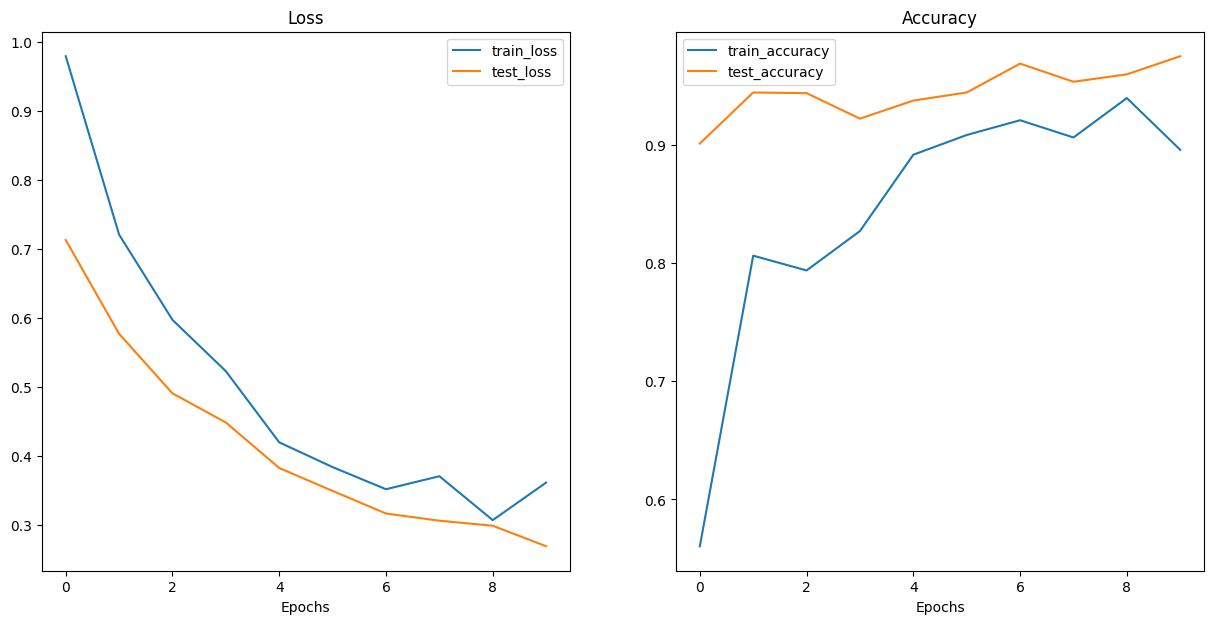

In [13]:
utils.plot_loss_curves(effnetb2_model_results)

### 1.2 ViT creation

In [14]:
# Create ViT model function for further use
def vit_model_create(num_class:int=3, in_features=768):

  weights = torchvision.models.ViT_B_16_Weights.DEFAULT
  model = torchvision.models.vit_b_16(weights = weights)
  transforms = weights.transforms()

  for p in model.parameters():
    p.requires_grad = False

  model.heads = nn.Sequential(
    nn.Linear(in_features=in_features, out_features=num_class))
  return model, transforms

In [15]:
vit_model, vit_transforms = vit_model_create()

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 198MB/s]


In [16]:
# Create dataloaders for ViT model
train_dataloader_vit, test_dataloader_vit, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=vit_transforms,
    batch_size=BATCH_SIZE
)

In [17]:
loss_fn_cross_entropy = nn.CrossEntropyLoss()
optimizer_adam = torch.optim.Adam(params=vit_model.parameters(), lr=1e-3)

In [18]:
# Train vit #11/10/25
start_time = timer()
vit_model_results = engine.train(
    model=vit_model.to(device),
    train_dataloader=train_dataloader_vit,
    test_dataloader=test_dataloader_vit,
    loss_fn=loss_fn_cross_entropy,
    optimizer= optimizer_adam,
    epochs=5,
    device = device
)
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.6518 | train_acc: 0.7562 | test_loss: 0.2472 | test_acc: 0.9597
Epoch: 2 | train_loss: 0.2193 | train_acc: 0.9437 | test_loss: 0.1251 | test_acc: 0.9750
Epoch: 3 | train_loss: 0.1488 | train_acc: 0.9604 | test_loss: 0.0950 | test_acc: 0.9875
Epoch: 4 | train_loss: 0.1303 | train_acc: 0.9667 | test_loss: 0.0833 | test_acc: 0.9812
Epoch: 5 | train_loss: 0.1055 | train_acc: 0.9708 | test_loss: 0.0745 | test_acc: 0.9875
Epoch: 6 | train_loss: 0.0861 | train_acc: 0.9750 | test_loss: 0.0640 | test_acc: 0.9938
Epoch: 7 | train_loss: 0.0758 | train_acc: 0.9812 | test_loss: 0.0614 | test_acc: 0.9875
Epoch: 8 | train_loss: 0.0693 | train_acc: 0.9854 | test_loss: 0.0603 | test_acc: 0.9875
Epoch: 9 | train_loss: 0.0617 | train_acc: 0.9938 | test_loss: 0.0588 | test_acc: 0.9875
Epoch: 10 | train_loss: 0.0586 | train_acc: 0.9938 | test_loss: 0.0566 | test_acc: 0.9875
Total training time: 89.691 seconds


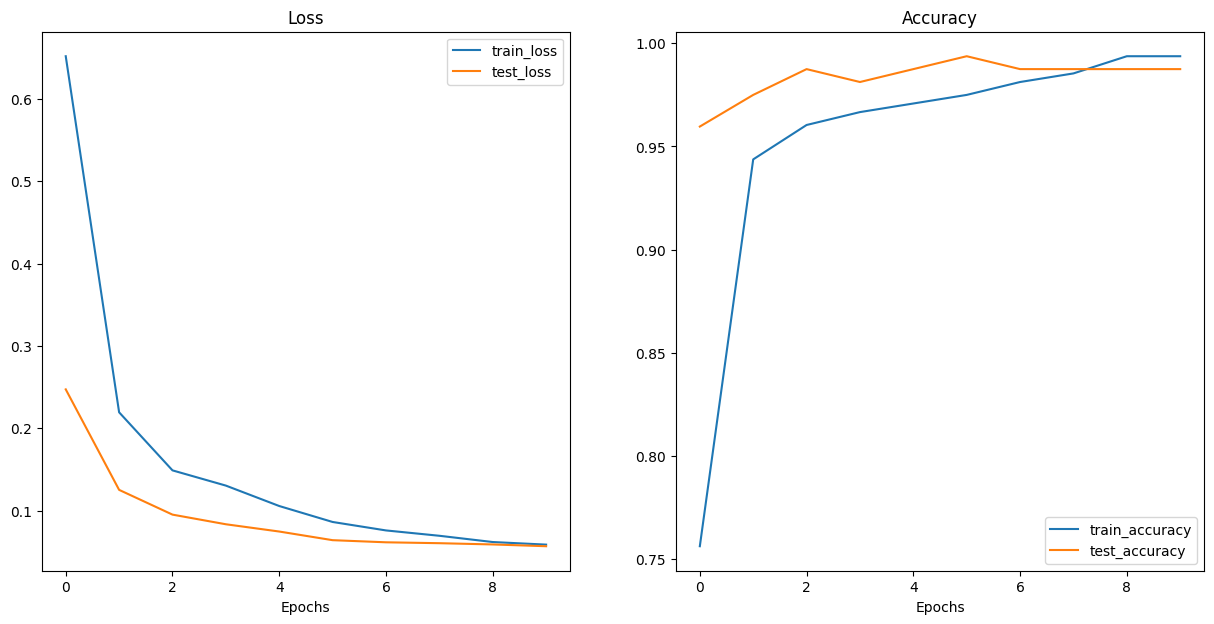

In [19]:
utils.plot_loss_curves(vit_model_results)

### 1.3 Get all images from the test path

In [20]:
# Get all images from the test paths
test_img_paths = list(Path(test_dir).glob("*/*.jpg"))
len(test_img_paths)
"cuda" if torch.cuda.is_available() else "cpu"

'cuda'

In [25]:
# Check how long it takes on average to make prediction
# Function loops through images and stores the result
def predict_store_av_result(
    paths: List[pathlib.Path],
    model: torch.nn.Module,
    transform: torchvision.transforms,
    class_names: List[str],
    device: str = "cuda" if torch.cuda.is_available() else "cpu") -> List[Dict]:

  pred_list = []
  model = model.to(device)
  model.eval()
  for p in tqdm(paths):
    iteration_pred = {}
    # Get the sample path and ground truth class name
    iteration_pred["image_path"] = p
    ground_truth_class_name = p.parent.stem
    iteration_pred["ground_truth_class_name"] = ground_truth_class_name

    start_time = timer()
    img = Image.open(p)
    img_transformed = transform(img).unsqueeze(0).to(device)

    with torch.inference_mode():
      pred_logits = model(img_transformed)
      pred_probs = torch.softmax(pred_logits, dim=1)
      pred_label = torch.argmax(pred_probs, dim=1)
      pred_class_name = class_names[pred_label.cpu()] # hardcode prediction class to be on CPU because Python variables reside on CPU
      iteration_pred["pred_prob"] = round(pred_probs.unsqueeze(0).max().cpu().item(), 4)
      iteration_pred["ground_truth_class_name"] = pred_class_name
      end_time = timer()
      iteration_pred["pred_time"] = round(end_time - start_time, 4)

    iteration_pred["correct"] = ground_truth_class_name == pred_class_name
    pred_list.append(iteration_pred)

  return pred_list


### 1.4 Make predictions

In [26]:
models_data = {
    "effnetb2": (effnetb2_model, effnetb2_transforms),
    "vit": (vit_model, vit_transforms)
}

processors = ["cpu", "cuda"]

# List for data outputs
pred_times = {}

for processor in processors:
  for model_name, (model, transforms) in models_data.items():
    combination = f"{model_name}_{processor}"
    print(f"Running predictions for {model_name} on {processor}")

    pred_times[combination] = predict_store_av_result(
      paths=test_img_paths,
      model=model,
      transform=transforms,
      class_names=class_names,
      device=processor
  )
  pred_times

Running predictions for effnetb2 on cpu


  0%|          | 0/150 [00:00<?, ?it/s]

Running predictions for vit on cpu


  0%|          | 0/150 [00:00<?, ?it/s]

Running predictions for effnetb2 on cuda


  0%|          | 0/150 [00:00<?, ?it/s]

Running predictions for vit on cuda


  0%|          | 0/150 [00:00<?, ?it/s]

### 1.5 Comparing results

In [27]:
pred_time_results = []

for key, timing_data in pred_times.items():
  model_name, processor = key.rsplit('_', 1)

  pred_time_results.append({
      "Model": model_name,
      "Processor": processor,
      "Average pred time": pd.DataFrame(timing_data)["pred_time"].mean()
  })

pred_time_results_df = pd.DataFrame(pred_time_results)

# Format the dataframe
pred_time_results_df.insert(0, '#', range(1, len(pred_time_results_df)+ 1))
pred_time_results_df.style.set_properties(**{'text-align': 'left'}) \
.set_table_styles([dict(selector='th', props=[('text-align', 'left')])]) \
.hide(axis='index')

#,Model,Processor,Average pred time
1,effnetb2,cpu,0.098080
2,vit,cpu,0.431093
3,effnetb2,cuda,0.018133
4,vit,cuda,0.018076


## Exercise 2. The ViT feature extractor seems to have more learning capacity (due to more parameters) than EffNetB2, how does it go on the larger 20% split of the entire Food101 dataset?

* Train a ViT feature extractor on the 20% Food101 dataset for 5 epochs

### 2.1 Create model and transform for ViT

In [ ]:
NUM_CLASSES_101 = 101

vit_model_101, vit_transforms_101 = vit_model_create(num_class=NUM_CLASSES_101)

food101_train_transform = torchvision.transforms.Compose([
    torchvision.transforms.TrivialAugmentWide(), vit_transforms_101
])

### 2.2 Get Data

In [ ]:
# Get data
data_dir_101 = Path("data")

# Setup training data
all_data_train = datasets.Food101(
    root=data_dir_101,
    split="train",
    transform=food101_train_transform,
    download=True
)

all_data_test = datasets.Food101(
    root=data_dir_101,
    split="test",
    transform=vit_transforms_101,
    download=True
)

food101_class_names = all_data_train.classes

In [ ]:
# Split data for faster experience
train_data_splitted, _ = data_setup.split_data(dataset=all_data_train,split_size=0.2)
print("\n")
test_data_splitted, _ = data_setup.split_data(dataset=all_data_test,split_size=0.2)


### 2.3 Creating DataLoaders

In [ ]:
NUM_WORKERS = os.cpu_count()
BATCH_SIZE = 32

train_dataloader_101= torch.utils.data.DataLoader(
    dataset = train_data_splitted,
    batch_size = BATCH_SIZE,
    shuffle = True,
    num_workers = NUM_WORKERS,
    pin_memory = True
)

test_dataloader_101 = torch.utils.data.DataLoader(
    dataset = test_data_splitted,
    batch_size = BATCH_SIZE,
    shuffle = False,
    num_workers = NUM_WORKERS,
    pin_memory = True
)

### 2.4 Training ViT

In [ ]:
optimizer_adam = torch.optim.Adam(params=vit_model_101.parameters(), lr=1e-3)
loss_fn_cross_entropy = nn.CrossEntropyLoss(label_smoothing=0.1)

# Move model to device
vit_model_101.to(device)

start_timer = timer()
vit_model_trained = engine.train(
    model=vit_model_101,
    train_dataloader=train_dataloader_101,
    test_dataloader=test_dataloader_101,
    loss_fn=loss_fn_cross_entropy,
    optimizer= optimizer_adam,
    epochs=5,
    device = device
)
end_timer = timer()
print(f"Total training time: {end_timer - start_timer:.2f} seconds")

In [ ]:
utils.plot_loss_curves(vit_model_trained)

below is not changed code|\

## Exercise 3. Make predictions across the 20% Food101 test dataset with the ViT feature extractor from exercise 2 and find the "most wrong" predictions
* The predictions will be the ones with the highest prediction probability but with the wrong predicted label.
* Write a sentence or two about why you think the model got these predictions wrong.

In [ ]:
# Make prediction on the entire dataset
vit_model_101.eval()
test_prediction_list = []
with torch.inference_mode():
  for X_test, y_test in test_dataloader_101:
    X_test, y_test = X_test.to(device), y_test.to(device)
    test_pred_logits = vit_model_101(X_test)
    pred_probs = torch.softmax(test_pred_logits, dim=1)
    pred_output = torch.argmax(pred_probs, dim=1)
    test_prediction_list.append(pred_output)
test_prediction_list = torch.cat(test_prediction_list)
test_prediction_list

In [ ]:
#Convert predictions to lists
pred_probs = test_prediction_list.cpu().tolist()
truth_labels = torch.cat([y_test for X_test, y_test in test_dataloader_101])
# create a truth list to store truth labels
truth_list = truth_labels.cpu().tolist()

# find mismatch
mismatched_preds = [(actual, pred) for actual, pred in zip(truth_list, pred_probs) if actual != pred]

# count mismatches
mismatch_count = Counter(mismatched_preds)
top_5_mismatches = mismatch_count.most_common(5)

# get top 5 wrong predictions
top_5_wrong_list = [(food101_class_names[actual], food101_class_names[pred], count) for (actual, pred), count in top_5_mismatches]
# print(f"Top 5 most wrong predictions:")
# for actual, pred, count in top_5_wrong_list:
#     print(f"Actual: {actual} | Prediction: {pred} | Count: {count}")



In [ ]:
#Store results of prediction in dataframe
top_5_wrong_list_df = pd.DataFrame(top_5_wrong_list,
                                   columns=[ 'Actual', 'Prediction', 'Count'])
top_5_wrong_list_df.insert(0, '#', range(1, len(top_5_wrong_list_df)+ 1))

top_5_wrong_list_df.style.set_properties(**{'text-align': 'left'}) \
.set_table_styles([dict(selector='th', props=[('text-align', 'left')])]) \
.hide(axis='index')

### 3.1 Reasons of mistakes on data
Based on the mistakes I see why fillet mignon and steak are confused, it is very similar food
The same with chocolate cake and chocoloate mousse, steak and por chops confused with baby_back_ribs is understandable

## Exercise 4. Evaluate the ViT feature extractor across the whole Food101 test dataset rather than just the 20% version, how does it perform?
* Does it beat the original Food101 paper's best result of 56.4% accuracy?

In [ ]:
# dataloader for all data
train_dataloader_all_data = torch.utils.data.DataLoader(
    dataset = all_data_train,
    batch_size = BATCH_SIZE,
    shuffle = True,
    num_workers = NUM_WORKERS,
    pin_memory = True
)

test_dataloader_all_data = torch.utils.data.DataLoader(
    dataset = all_data_test,
    batch_size = BATCH_SIZE,
    shuffle = False,
    num_workers = NUM_WORKERS,
    pin_memory = True
)

In [ ]:
# Move model to device
vit_model_101.to(device)

# Make prediction on the entire dataset
vit_model_101.eval()
test_prediction_list = []
with torch.inference_mode():
  for X_test, y_test in test_dataloader_all_data:
    X_test, y_test = X_test.to(device), y_test.to(device)
    test_pred_logits = vit_model_101(X_test)
    pred_probs = torch.softmax(test_pred_logits, dim=1)
    pred_output = torch.argmax(pred_probs, dim=1)
    test_prediction_list.append(pred_output)
test_prediction_list = torch.cat(test_prediction_list)
test_prediction_list

In [ ]:
#Convert predictions to lists
from collections import Counter
pred_probs = test_prediction_list.cpu().tolist()
truth_labels = torch.cat([y_test for X_test, y_test in test_dataloader_all_data])

truth_list = truth_labels.cpu().tolist()

# find mismatch
mismatched_preds = [(actual, pred) for actual, pred in zip(truth_list, pred_probs) if actual != pred]

# count mismatches
mismatch_count = Counter(mismatched_preds)
top_5_mismatches = mismatch_count.most_common(5)

# get top 5 wrong predictions
top_5_wrong_list = [(food101_class_names[actual], food101_class_names[pred], count) for (actual, pred), count in top_5_mismatches]

In [ ]:
#Store results of prediction in dataframe
top_5_wrong_list_df = pd.DataFrame(top_5_wrong_list,
                                   columns=[ 'Actual', 'Prediction', 'Count'])
top_5_wrong_list_df.insert(0, '#', range(1, len(top_5_wrong_list_df)+ 1))

top_5_wrong_list_df.style.set_properties(**{'text-align': 'left'}) \
.set_table_styles([dict(selector='th', props=[('text-align', 'left')])]) \
.hide(axis='index')

## Exercise 5. Head to [Paperswithcode.com](https://paperswithcode.com/) and find the current best performing model on the Food101 dataset.
* What model architecture does it use?

The Bamboo ViT B/16 model achieves 92.8% accuracy on the Food-101 dataset github. This model was pre-trained on the Bamboo dataset, which is a mega-scale vision dataset that consists of 69M image classification annotations across 119K categories - approximately 4 times larger than ImageNet.
The Bamboo project's approach is  building large-scale datasets using human-machine synergy and active learning. The Vision Transformer (ViT) B/16 variant trained on this extensive dataset demonstrates superior performance compared to other approaches on the Food-101 benchmark, which is a challenging dataset containing 101,000 images across 101 food categories.

## Exercise 6. Write down 1-3 potential failure points of our deployed FoodVision models and what some potential solutions might be.
* For example, what happens if someone was to upload a photo that wasn't of food to our FoodVision Mini model?

1. When upload a photo that is not food, it will still try to define the
2. When upload a food photo that is not in the class list
3. It will define a food that is in the trained dataset but still get it wrong

